In [1]:
# --- CELL 1: SETUP ---
import os
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [2]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    draft: str
    critique: str
    iteration_count: int
    max_iterations: int

In [3]:
# --- CELL 3: THE WORKERS (NODES) ---

def writer_node(state: SentinelState):
    """Creates or improves the draft based on the critique."""
    count = state.get("iteration_count", 0)
    print(f"✍️ Writer: Working on version {count + 1}...")

    if count == 0:
        content = "The market is up today because of tech stocks."
    else:
        content = f"Market Analysis V{count+1}: Major indices surged today, led by a 2% rally in the semiconductor sector following strong earnings."

    return {"draft": content, "iteration_count": count + 1}

In [4]:
def critic_node(state: SentinelState):
    """Reviews the draft and provides feedback."""
    print("🧐 Critic: Reviewing draft...")
    draft = state["draft"]

    # Simulating feedback logic
    if "semiconductor" not in draft.lower():
        feedback = "Too vague. Please mention specific sectors like semiconductors."
    else:
        feedback = "Excellent. This is production-ready."

    return {"critique": feedback}

In [5]:
# --- CELL 4: THE REFINEMENT LOGIC (THE LOOP) ---
def should_refine(state: SentinelState):
    """Decides if we need another pass or if we are done."""
    # Exit if the critic is happy OR if we hit the safety limit
    if "production-ready" in state["critique"].lower() or state["iteration_count"] >= state["max_iterations"]:
        print("✅ Quality Check Passed (or Max Iterations reached).")
        return "finish"

    print("🔄 Needs improvement. Sending back to Writer...")
    return "refine"

In [6]:
# --- CELL 5: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

builder.add_node("writer", writer_node)
builder.add_node("critic", critic_node)

builder.add_edge(START, "writer")
builder.add_edge("writer", "critic")

# The loop: The critic sends it back to the writer until it's ready
builder.add_conditional_edges(
    "critic",
    should_refine,
    {
        "refine": "writer",
        "finish": END
    }
)

sentinel_refinement = builder.compile()

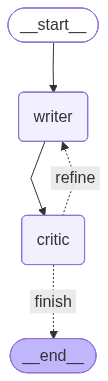

In [7]:
# --- CELL 6: VISUALIZATION ---
try:
    png_bytes = sentinel_refinement.get_graph().draw_mermaid_png()
    with open("sentinel_refinement.png", "wb") as f:
        f.write(png_bytes)
    display(Image(data=png_bytes))
except Exception as e:
    print(f"Visualization skip: {e}")

In [8]:
# --- CELL 7: RUNNING THE LINE ---
print("\n--- STARTING REFINEMENT CYCLE ---")
result = sentinel_refinement.invoke({"max_iterations": 3})
print("\n" + "="*30)
print(f"FINAL VERSION:\n{result['draft']}")
print("="*30)


--- STARTING REFINEMENT CYCLE ---
✍️ Writer: Working on version 1...
🧐 Critic: Reviewing draft...
🔄 Needs improvement. Sending back to Writer...
✍️ Writer: Working on version 2...
🧐 Critic: Reviewing draft...
✅ Quality Check Passed (or Max Iterations reached).

FINAL VERSION:
Market Analysis V2: Major indices surged today, led by a 2% rally in the semiconductor sector following strong earnings.
